In [1]:
import torch
import csv
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

In [10]:
with open("mnist_train.csv", "r") as read_obj:
    csv_reader = csv.reader(read_obj)
    train = list(csv_reader)
train = train[1:]
train = [[int(train[i][j]) for j in range(len(train[0]))] for i in range(len(train))]
train = torch.tensor(train, dtype = torch.float32)


In [11]:
train_Y = train[:,0].long()
train_X = train[:,1:]

dataset = TensorDataset(train_X, train_Y)

batch_size = 16
dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True)




206
tensor(0.)


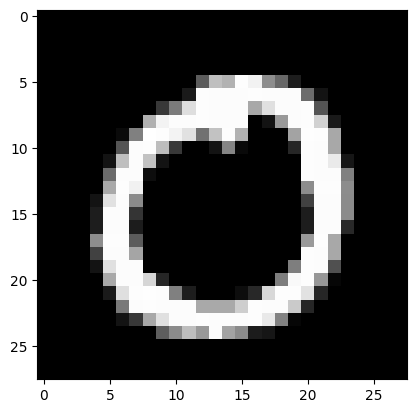

In [4]:
n = int(torch.floor(1000*torch.rand(1)))
test = train_X[n].reshape((28,28))
print(n)
print(train_Y[n])
plt.imshow(test, cmap = "gray")

In [24]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

learning_rate = 0.001
lossF = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [22]:
def train(epoch):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    for i, (inputs, labels) in enumerate(dataloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = lossF(outputs, labels)

        with torch.no_grad():
            preds = torch.argmax(outputs, dim = 1)
            correct = (preds == labels)
            accuracy = correct.float().sum()
            running_acc += accuracy

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    print(f'Epoch {epoch}, Loss: {running_loss:.4f}, Acc: {running_acc/60000}')
    running_loss = 0


In [25]:
epochs = 10
for epoch in range(epochs):
    train(epoch)

Epoch 0, Loss: 2337.4836, Acc: 0.899233341217041
Epoch 1, Loss: 1278.5704, Acc: 0.9240666627883911
Epoch 2, Loss: 1143.9484, Acc: 0.9334333539009094
Epoch 3, Loss: 1105.0324, Acc: 0.9373000264167786
Epoch 4, Loss: 1056.3503, Acc: 0.9419500231742859
Epoch 5, Loss: 992.4795, Acc: 0.9441333413124084
Epoch 6, Loss: 1014.8863, Acc: 0.944433331489563
Epoch 7, Loss: 1005.9739, Acc: 0.9465333223342896
Epoch 8, Loss: 937.9140, Acc: 0.9500166773796082
Epoch 9, Loss: 932.7146, Acc: 0.9503999948501587
